##### Instructions
- Keep the original structure, you may add additional code cells and/or mark-down cells for clarity, legibility and/or structure.
- Add the required descriptions, explanations, justifications to the mark-down cells. You can find more mark-down tips & tricks online, for example [here](https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html) and [here](https://www.ibm.com/docs/en/watson-studio-local/1.2.3?topic=notebooks-markdown-jupyter-cheatsheet)

# EXAM03: Data Science Group Assignment - Iteration 1

**Group name:** [Be Right Back]

**Student names & numbers:**
* [Rick de Cuijper] - [Student no.100097]
* [Bart Geijtenbeek] - [Student no.97543]
* [Boaz Vaneveld] - [Student no.101529]


---

## 0. Iteration setup

**Import libraries**

In [1]:
# CODE CELL: import the necessary libraries for this iteration
# setup the venv by [venv\Scripts\activate]

import pandas as pd;
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

**Load dataset(s)**

In [30]:
# CODE CELL: import the necessary dataset(s) for this iteration

# head is used to see proof of loading the correct dataset and to see if the data gets correcty loaded 
# and unlike .sample() it is not random with is useful because we use github as collaboration tool 
# and in pull req the code gets messy since this is a jupyter notebook 
# and this is why we do not want to use random outputs.

df_ships = pd.read_csv("ships_inventory_iter1.csv");
df_ships.head(10)

,Ship_ID,Galactic_Credits,Model_Cycle,Ship_Manufacturer,Sector
0,7316160254,4950,7505.0,Galactic Motors,Mon Cala Ocean Worlds
1,7316115206,18999,7518.0,Galactic Motors,Thraxos Blockade
2,7315865657,4000,7486.0,Republic Aerospace,Indoumodo Sector
3,7314772431,6495,7511.0,Nebula Industries,Pantora Moon
4,7311539325,3995,7499.0,Corellian Engineering,Malastare Narrows
5,7313451637,25990,7519.0,Republic Aerospace,Calodan Expanse
6,7316546982,4000,7509.0,General Mining Corp,Mimban Swamp
7,7311754900,7999,7508.0,Hondo Systems,Mon Cala Ocean Worlds
8,7313137564,5999,7497.0,Bayerische Motoren Wormhole,Iridonia Belt
9,7302916705,58995,7517.0,General Mining Corp,Wroona Spaceport


---

## 1. Business Understanding
*Rubric: LO 6.4D (Reflection on Process)*

**Situation description**

*Describe the Nebula Brokerage pricing problem. Why is their current "gut feeling" approach a risk?.*

**Business objective(s)**

*Justify why a data-driven baseline is needed*

**Data mining goal(s)**

*Explain what type of modeling task this is and why.*

**Success criteria**

*Determine success criteria for this iteration (the benchmark)*

---

## 2. Data Understanding
*Rubric: LO 7.3Q (Visuals) & LO 6.4C (Process)*

**Data exploration**

*Include summary statistics and descriptions of data types below. Describe your findings.*

In [31]:
# CODE CELL: Show basic statistics and information

# I use print to call all 3 funtions

print(df_ships.info())
print(df_ships.describe())
print(df_ships.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 368814 entries, 0 to 368813
Data columns (total 5 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Ship_ID            368814 non-null  int64  
 1   Galactic_Credits   368814 non-null  int64  
 2   Model_Cycle        361408 non-null  float64
 3   Ship_Manufacturer  368814 non-null  object 
 4   Sector             368814 non-null  object 
dtypes: float64(1), int64(2), object(2)
memory usage: 14.1+ MB
None
            Ship_ID  Galactic_Credits    Model_Cycle
count  3.688140e+05     368814.000000  361408.000000
mean   7.311485e+09      19453.536818    7511.264529
std    4.381124e+06      15540.472943       9.078571
min    7.301583e+09        501.000000    7400.000000
25%    7.308105e+09       7950.000000    7508.000000
50%    7.312604e+09      15990.000000    7513.000000
75%    7.315245e+09      27990.000000    7517.000000
max    7.317101e+09     777777.000000    7522.000000
Sh

### We observed that:

The dataset contains information on **368,814 ships**, including their cost in **Galactic Credits, model age (Model_Cycle), manufacturer, and sector.** Most of the data appears to be complete, although the Model_Cycle variable has **7406 missing values**. The dataset includes both numerical variables (Ship_ID, Galactic_Credits, and Model_Cycle) and categorical variables (objects: Ship_Manufacturer and Sector). This mix of data types makes it possible to explore different patterns in the data, such as identifying which manufacturers tend to produce more expensive ships or which sectors have the highest concentration of ships.

**Visualizations and patterns**

*Discover patterns in the data by creating visualizations. Create at least a histogram of Galactic_Credits. Describe your observations.*

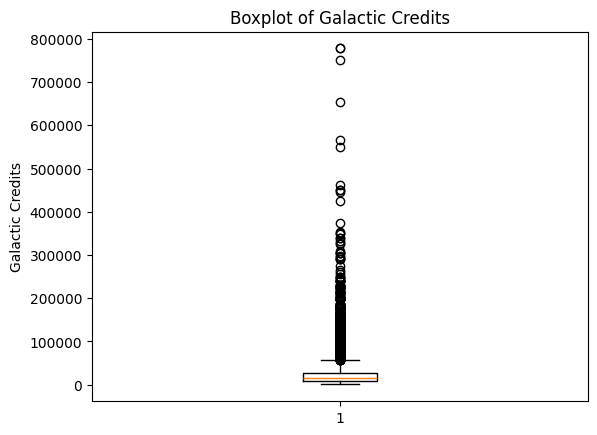

In [ ]:
# CODE CELL: Generate visualizations (e.g., scatter plots, histograms)

# here we use a boxplot to see the outliers 

plt.boxplot(df_ships['Galactic_Credits'])
plt.title('Boxplot of Galactic Credits')
plt.ylabel('Galactic Credits')
plt.show()

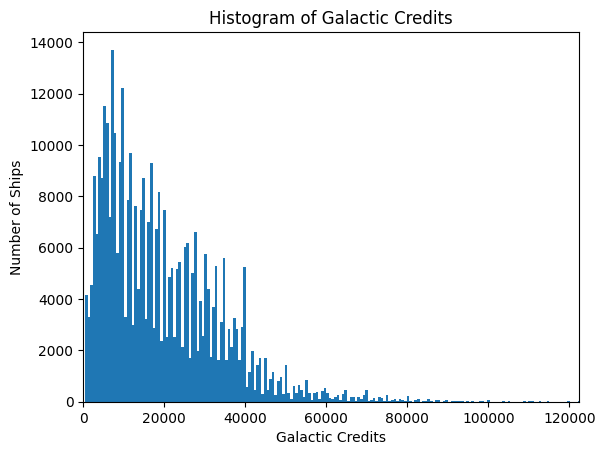

In [46]:
# CODE CELL: Generate visualizations (e.g., scatter plots, histograms)

# here we make a histogram to visualise our data

plt.hist(df_ships['Galactic_Credits'], bins="auto")
plt.title('Histogram of Galactic Credits')
plt.xlabel('Galactic Credits')
plt.ylabel('Number of Ships')
plt.xlim(0, df_ships['Galactic_Credits'].quantile(0.999))
plt.show()

### We observed that:

In this case, we used a boxplot to represent the outliers in the dataset, and we used a histogram to represent the median of the dataset.

#### Boxplot:

The boxplot shows the median and the outliers in our dataset; this is why we used it.  
We also used it to make the histogram less obscure by separating the median and outliers into separate diagrams.

#### Histogram:

We used the histogram to visualize our data and the median, not outliers; that is why we capped it at the 0.999 quantile, which falls around 120,000 entries, and the first outliers, to capture the majority of our data.  
We also set the bins to auto, which we thought was best to capture the most logical distribution of the data.  
Aside from that, our data is right-skewed: most ships have relatively lower prices, while a small number of very expensive ships create a long tail toward higher values. This indicates that a small proportion of ships contribute disproportionately to the highest price values in the dataset.

## Data Insights and Data Quality

### Insights
- The dataset contains **368,814 ships** with information on cost (`Galactic_Credits`), model age (`Model_Cycle`), manufacturer (`Ship_Manufacturer`), and sector (`Sector`).  
- **Distribution of ship prices** is strongly **right-skewed**: most ships are relatively affordable, while a small number of ships are extremely expensive, creating a long tail in the histogram.  
- Numerical features include `Ship_ID`, `Galactic_Credits`, and `Model_Cycle`, while categorical features include `Ship_Manufacturer` and `Sector`.  
- This mix allows analysis such as:  
  - Which manufacturers produce the most expensive ships  
  - Which sectors have the highest number of ships  
  - How model age relates to price  

### Data Quality Issues
- **Missing values:** A small number of ships have missing `Model_Cycle` information; other columns are mostly complete.  
- **Duplicates:** There may be duplicate `Ship_ID`s or records; these should be checked and handled if necessary.  
- **Outliers:** Extreme `Galactic_Credits` values exist (luxury or rare ships), which can affect visualizations and statistical analyses. Limiting plots to the 99.9th percentile helps visualize the main distribution without the extreme values stretching the axes.  

---

## 3. Data Preparation
*Rubric: LO 6.4C (Data Science Steps)*

**Cleaning and preprocessing**
*Describe and justify steps taken (e.g., imputation, handling outliers, fixing other errors).*

In [ ]:
# CODE CELL: Data cleaning and preprocessing steps

**Adjusting dataset (optional)**
*If you adjusted the dataset for modeling in additional ways, describe that here*

In [5]:
# OPTIONAL CODE CELL: Additional preprocessing steps

---

## 4. Modeling
*Rubric: LO 6.4C (Data Science Steps)*

**Model setup**
*Describe and justify the creation of your simple benchmark model to predict Galactic_Credits*

In [ ]:
# CODE CELL: Model training and setup code

**Testing and performance**
*Describe how you tested the model and interpret the metrics. Make sure to present the metrics in a clear overview.*

In [1]:
# CODE CELL: Model evaluation code

---

## 5. Evaluation
*Rubric: LO 6.4C (Results vs. Objectives)*

**Assessment against succes criteria** 
*What is the difference between the metrics? What does this mean? Did you meet the goals set in the Business Understanding?*

**Key findings and limitations**
*What did you learn? What are the limitations of this current model?*

---

## 6 Personal Contribution
*Rubric: LO 7.3P (Equal Contribution)*

| Student name | Contribution | Personal lessons learned |
| :--- | :--- | :--- |
| Student name 1 | *Contribution description* | *Personal lessons learned this iteration* |
| Student name 2 | *Contribution description* | *Personal lessons learned this iteration* |
| Student name 3 | *Contribution description* | *Personal lessons learned this iteration* |